In [1]:
import seaborn as sbn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
spdf = pd.read_csv("student_performance_dataset.csv")

In [27]:
missing_cols = ['social_media_hours',
                'focus_score',
                'sleep_hours']

In [ ]:
miss_df = spdf[missing_cols].isnull()

In [44]:
miss_df.sum(axis=1).value_counts()

0    2823
1     174
2       3
Name: count, dtype: int64

In [68]:
num_df = spdf.select_dtypes(include='number')

In [69]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [70]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

In [71]:
imputer = KNNImputer(n_neighbors=5,weights='distance')
imputed_scaled = imputer.fit_transform(scaled_data)
imputed_data = scaler.inverse_transform(imputed_scaled)


In [72]:
num_df = pd.DataFrame(imputed_data,columns=num_df.columns, index=num_df.index)

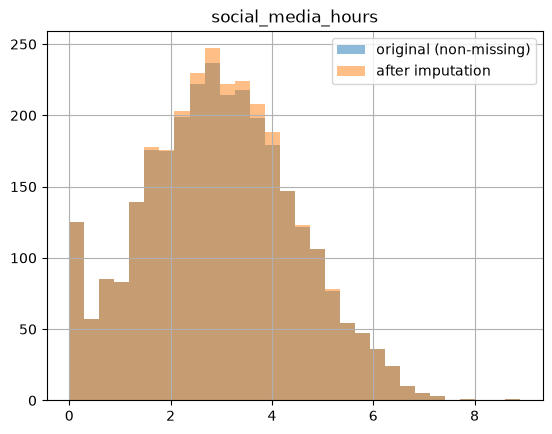

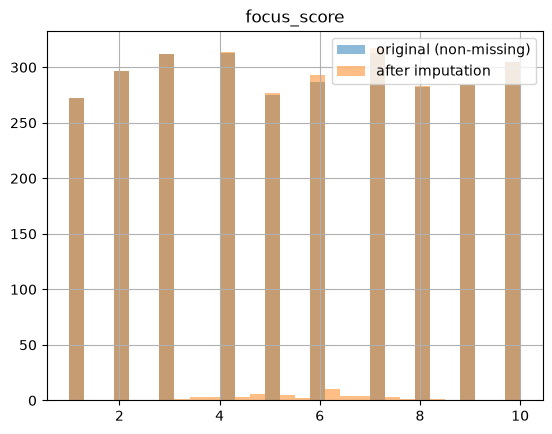

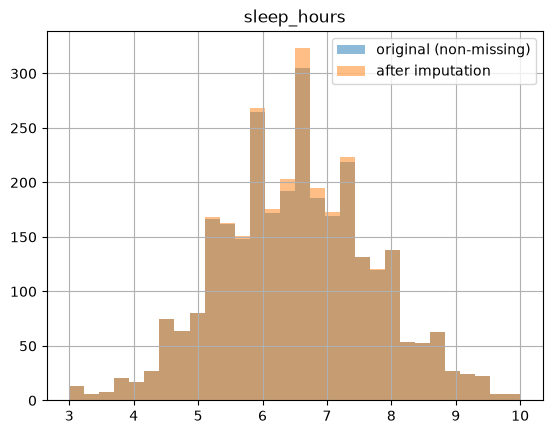

In [78]:
for col in missing_cols:
    fig, ax = plt.subplots()
    spdf[col].dropna().hist(bins=30, alpha=0.5, label='original (non-missing)', ax=ax)
    num_df[col].hist(bins=30, alpha=0.5, label='after imputation', ax=ax)
    ax.legend()
    ax.set_title(col)
    plt.show()

In [79]:
print(spdf[missing_cols].corr())
print(num_df[missing_cols].corr())

                    social_media_hours  focus_score  sleep_hours
social_media_hours            1.000000    -0.002849     0.016038
focus_score                  -0.002849     1.000000    -0.015634
sleep_hours                   0.016038    -0.015634     1.000000
                    social_media_hours  focus_score  sleep_hours
social_media_hours            1.000000    -0.006435     0.014584
focus_score                  -0.006435     1.000000    -0.013096
sleep_hours                   0.014584    -0.013096     1.000000


In [88]:
num_df.columns

Index(['student_id', 'age', 'study_hours_per_day', 'deep_work_sessions',
       'assignment_completion_rate', 'attendance_percentage',
       'social_media_hours', 'doomscrolling_before_sleep',
       'notification_distractions', 'ai_tool_usage_hours', 'gaming_hours',
       'stress_level', 'motivation_level', 'focus_score',
       'procrastination_index', 'sleep_hours', 'caffeine_intake',
       'physical_activity_hours', 'internet_quality', 'family_support',
       'financial_stress', 'productivity_after_midnight',
       'revision_efficiency', 'burnout_risk', 'consistency_score',
       'final_exam_score', 'n_missing'],
      dtype='str')

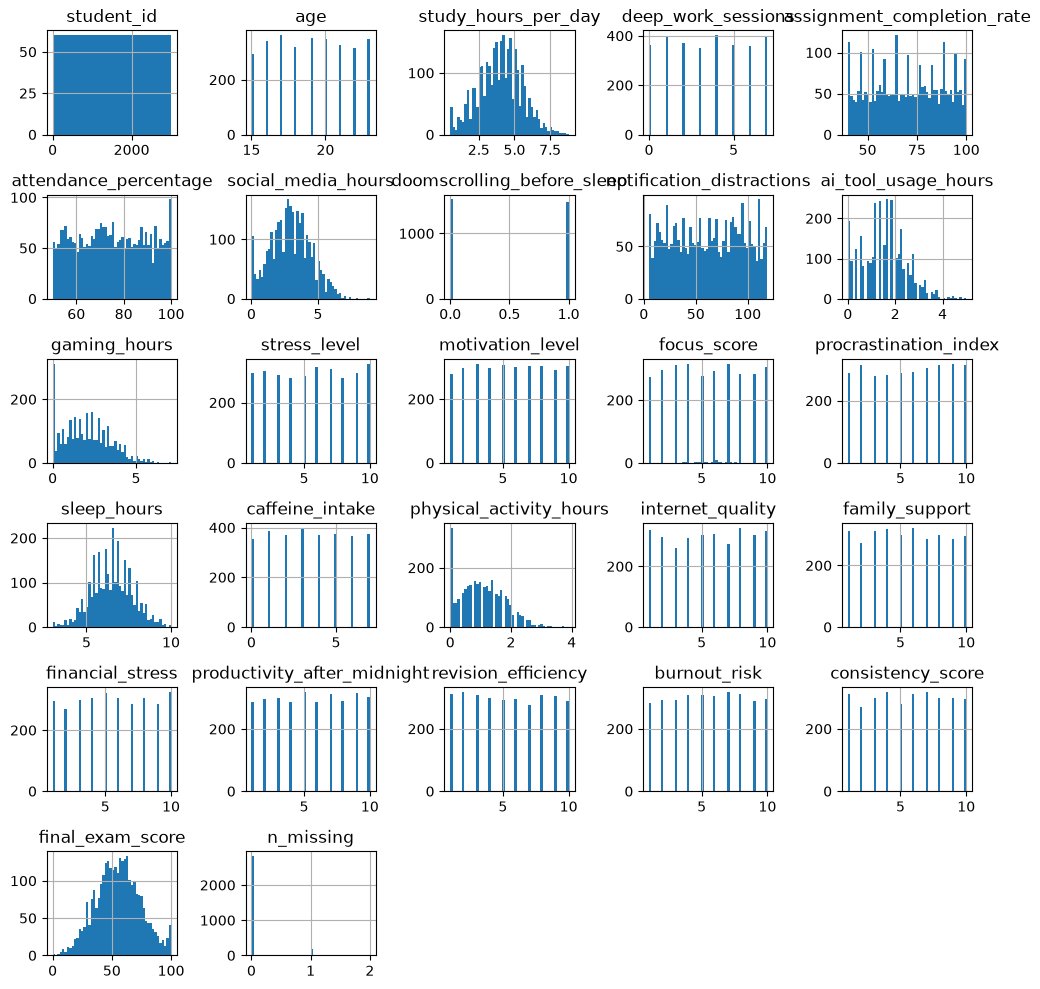

In [92]:
num_df.hist(figsize=(10,10),bins=50)
plt.tight_layout()
plt.show()

In [117]:
outlier_mask = pd.Series(False, index=num_df.index)  # start with all False, same length as your df

for col in num_df.columns:
    q1 = num_df[col].quantile(0.25)
    q3 = num_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    col_outlier = (num_df[col] < lower_bound) | (num_df[col] > upper_bound)
    outlier_mask = outlier_mask | col_outlier  # combine with OR across columns

print(outlier_mask.sum())  # total rows with at least one outlier

# drop those rows
df_clean = num_df[~outlier_mask]

252


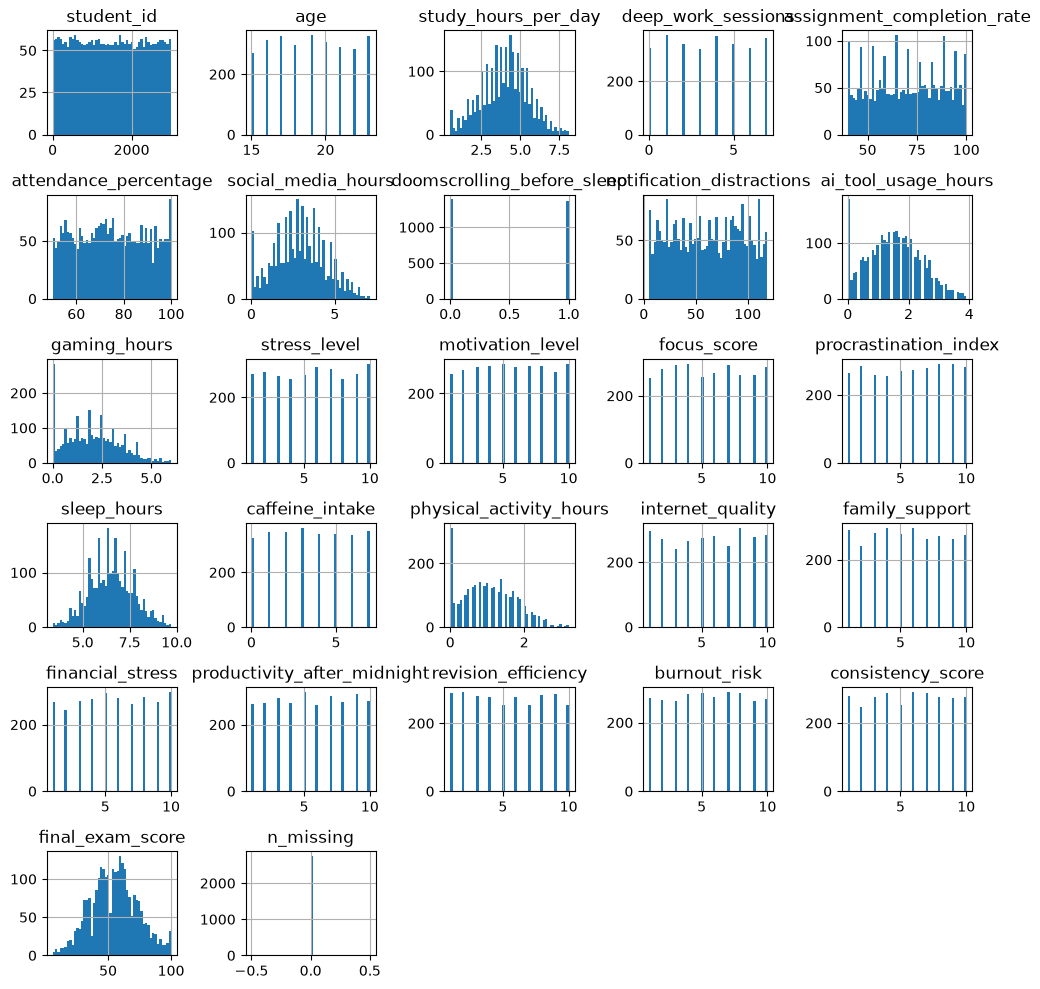

In [118]:
df_clean.hist(figsize=(10,10),bins = 50)
plt.tight_layout()
plt.show()

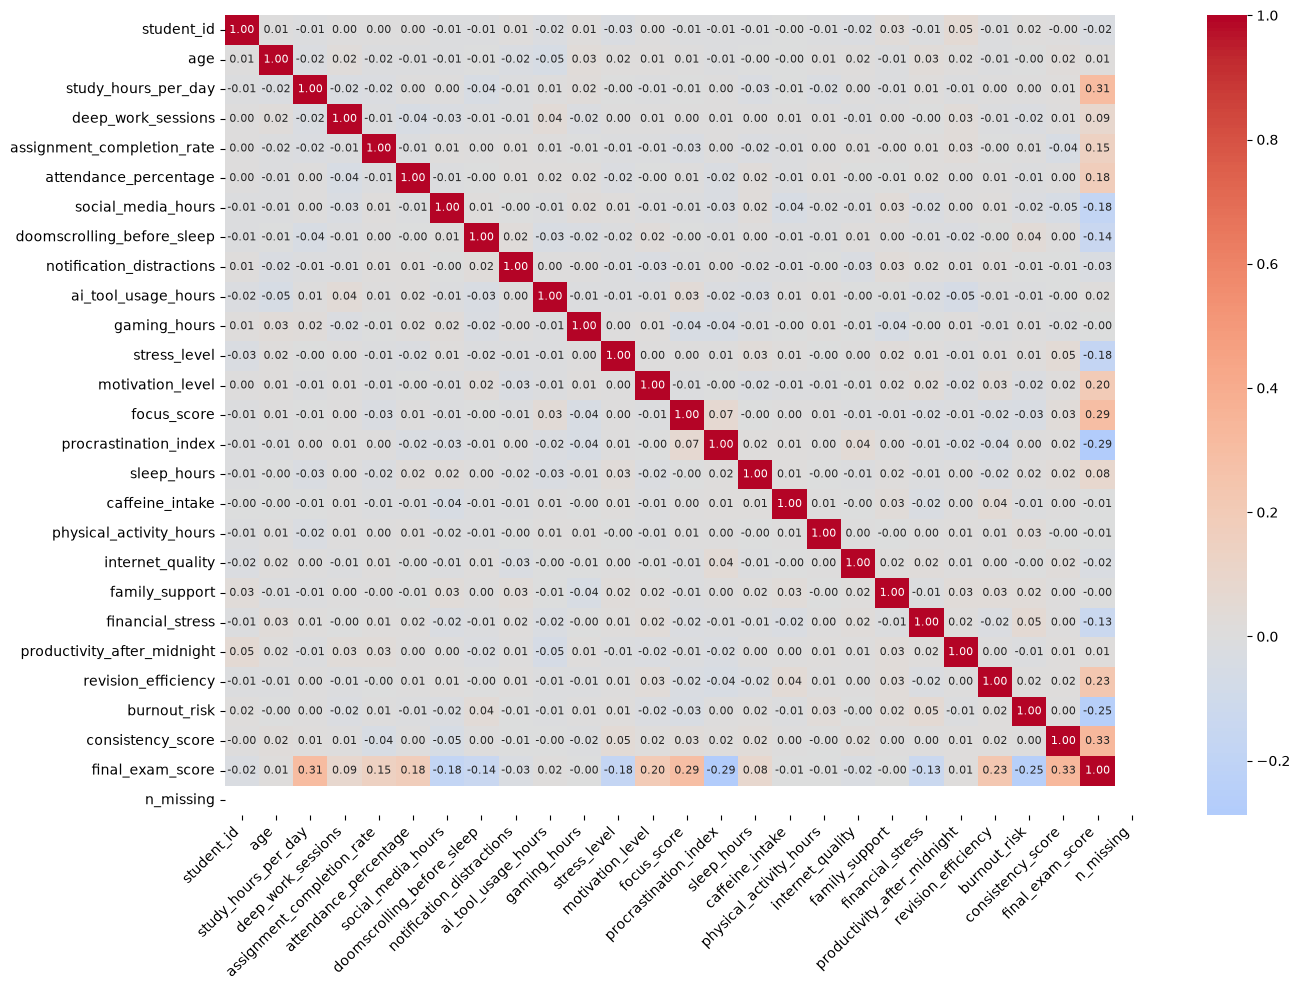

In [120]:
plt.figure(figsize=(14,10))
sbn.heatmap(df_clean.corr(),annot=True,cmap='coolwarm',center=0,fmt='.2f',annot_kws={'size':8})
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [121]:
pairplot_columns = ['final_exam_score','study_hours_per_day','assignment_completion_rate','attendance_percentage','social_media_hours',
                    'doomscrolling_before_sleep',
                    'ai_tool_usage_hours',
                    'stress_level',
                    'motivation_level',
                    # 'focus_score',
                    # 'procrastination_index',
                    # 'sleep_hours',
                    # 'financial_stress',
                    # 'revision_efficiency',
                    # 'burnout_risk',
                    ]

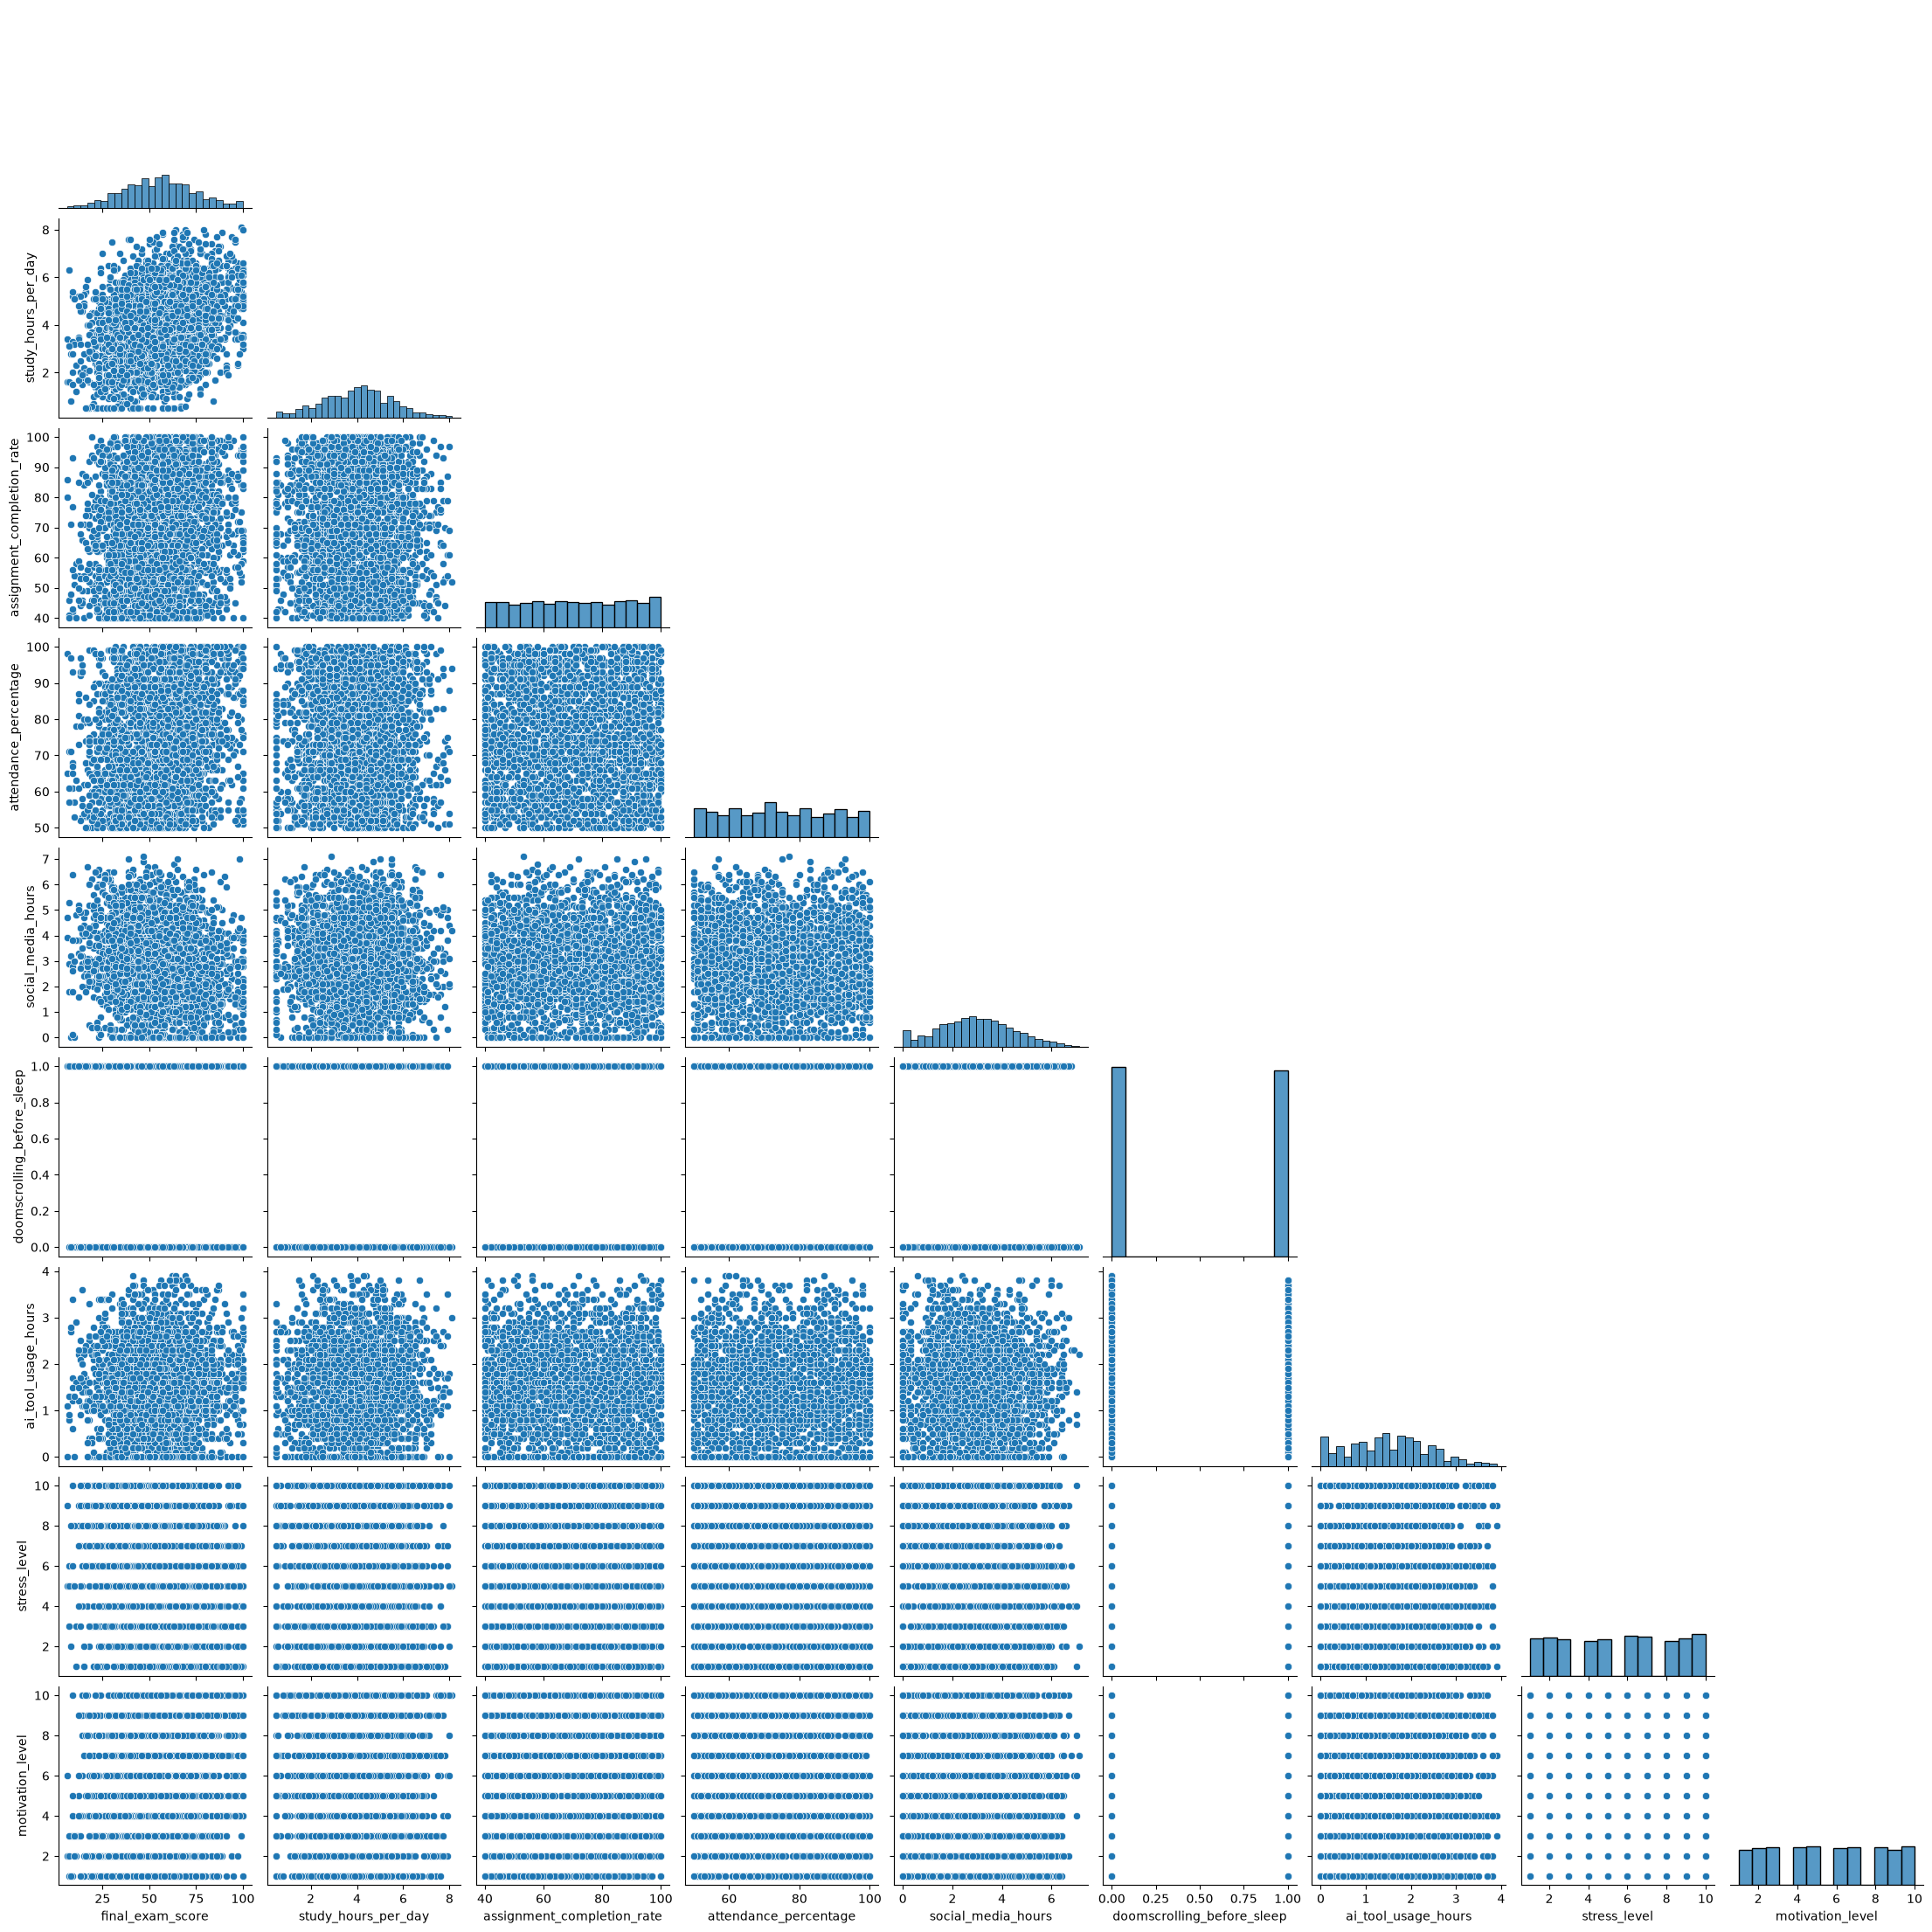

In [122]:
sbn.pairplot(df_clean[pairplot_columns],corner=True)
plt.show()

In [123]:
# df_clean = df_clean.corr()['final_exam_score'].sort_values(ascending=False)

In [129]:
corr_col = ['study_hours_per_day','assignment_completion_rate','attendance_percentage','social_media_hours',
                    'doomscrolling_before_sleep',
                    'ai_tool_usage_hours',
                    'stress_level',
                    'motivation_level',
                    'focus_score',
                    'procrastination_index',
                    'sleep_hours',
                    'financial_stress',
                    'revision_efficiency',
                    'burnout_risk',
                    ]

In [126]:
df_clean = df_clean.drop(columns=['student_id','n_missing'])

In [128]:
feature_corr = df_clean[corr_col].corr()
high_corr = feature_corr.where((feature_corr.abs()>0.7) & (feature_corr.abs()<1.0))
high_corr.stack().drop_duplicates()

final_exam_score  final_exam_score   NaN
dtype: float64

In [144]:
from sklearn.model_selection import train_test_split

X = df_clean[corr_col]
y = df_clean['final_exam_score']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [131]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [132]:
from sklearn.metrics import r2_score

y_pred = rf.predict(X_test)
r2 = r2_score(y_test,y_pred)
print(r2)

0.48677619658723836


In [133]:
train_r2 = r2_score(y_train,rf.predict(X_train))

In [134]:
train_r2

0.9275295206768006

In [135]:
importances = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)
print(importances)

study_hours_per_day           0.137299
focus_score                   0.116276
procrastination_index         0.106897
social_media_hours            0.082675
burnout_risk                  0.076790
attendance_percentage         0.074333
motivation_level              0.068547
assignment_completion_rate    0.068414
revision_efficiency           0.066132
sleep_hours                   0.053845
stress_level                  0.051650
ai_tool_usage_hours           0.042338
financial_stress              0.041127
doomscrolling_before_sleep    0.013679
dtype: float64


In [136]:
from sklearn.model_selection import cross_val_score

In [137]:
cv_scores = cross_val_score(rf,X,y,cv=5,scoring='r2')
print(f"CV R^2 scores: {cv_scores} Mean: {cv_scores.mean()}, STD: {cv_scores.std()}")

CV R^2 scores: [0.4532246  0.46639221 0.45816584 0.48081883 0.46610821] Mean: 0.4649419379680351, STD: 0.00936750381261135


In [138]:
rf = RandomForestRegressor(n_estimators=200,
                           max_depth=6,
                           min_samples_leaf=10,
                           min_samples_split=20,
                           random_state=42)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [146]:
y_pred = rf.predict(X_test)
r2 = r2_score(y_test,y_pred)
y_train_pred = rf.predict(X_train)
train_r2 = r2_score(y_train,y_train_pred)

print(f"Test R2: {r2} and the Train R2: {train_r2}")

Test R2: 0.41931401059441653 and the Train R2: 0.5608056609762491


In [148]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'min_samples_split': [2, 10, 20, 30],
    'n_estimators': [100, 200, 300]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

KeyboardInterrupt: 